DATA ANALYSIS & VISUALIZATION ASSIGNMENT

# Data Analysis & Visualization

This project examines system login records to better understand user access behavior and identify potential security concerns. The dataset includes information such as login time, user identity, location, device type, and whether the login attempt was successful.

The analysis focuses on uncovering patterns in login activity, especially failed attempts, repeated access by the same users, and logins from different geographical locations. These patterns can help reveal unusual or potentially risky behavior within the system.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("system_logins.csv")
df.head()

In [ ]:
df.info()
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   timestamp   30 non-null     str  
 1   user_id     30 non-null     str  
 2   ip_address  30 non-null     str  
 3   country     30 non-null     str  
 4   success     30 non-null     bool 
 5   os          30 non-null     str  
dtypes: bool(1), str(5)
memory usage: 1.3 KB


,timestamp,user_id,ip_address,country,success,os
count,30,30,30,30,30,30
unique,30,26,26,10,2,5
top,2024-03-01 08:15:23,user101,192.168.1.10,Uganda,True,Windows
freq,1,4,4,10,18,11


The dataset contains 30 entries with no missing values.
Most columns are categorical except 'success' which is boolean.

In [ ]:
# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Check duplicates
df.duplicated().sum()

np.int64(0)

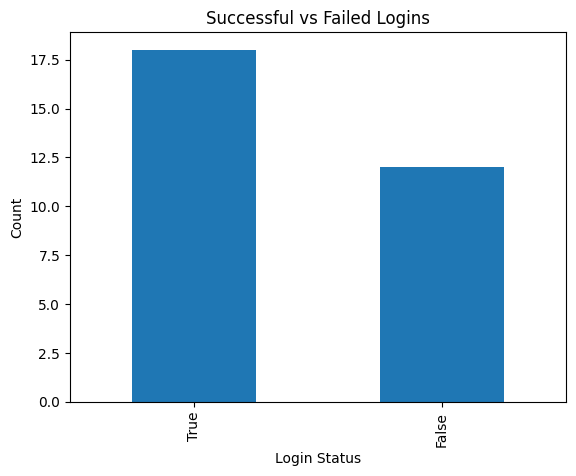

In [ ]:
df['success'].value_counts()

df['success'].value_counts().plot(kind='bar')
plt.title("Successful vs Failed Logins")
plt.xlabel("Login Status")
plt.ylabel("Count")
plt.show()

There are more successful logins than failed ones, but failed attempts still exist and may indicate security threats.

In [ ]:
failed_logins = df[df['success'] == False]
failed_logins['user_id'].value_counts()

user_id
user103    1
user104    1
user106    1
user109    1
user102    1
user112    1
user114    1
user117    1
user119    1
user121    1
user124    1
user126    1
Name: count, dtype: int64

Some users have multiple failed attempts, which may indicate brute-force attacks or unauthorized access attempts.

In [ ]:
def risk_score(row):
    score = 0
    if row['success'] == False:
        score += 2
    if row['country'] not in ['Uganda']:
        score += 1
    return score

df['risk_score'] = df.apply(risk_score, axis=1)

df[['user_id', 'country', 'success', 'risk_score']].head()

,user_id,country,success,risk_score
0,user101,Uganda,True,0
1,user102,Kenya,True,1
2,user103,Nigeria,False,3
3,user101,Uganda,True,0
4,user104,USA,False,3


A simple risk scoring system was introduced to highlight potentially suspicious login attempts. Failed logins and foreign locations increase the risk score.

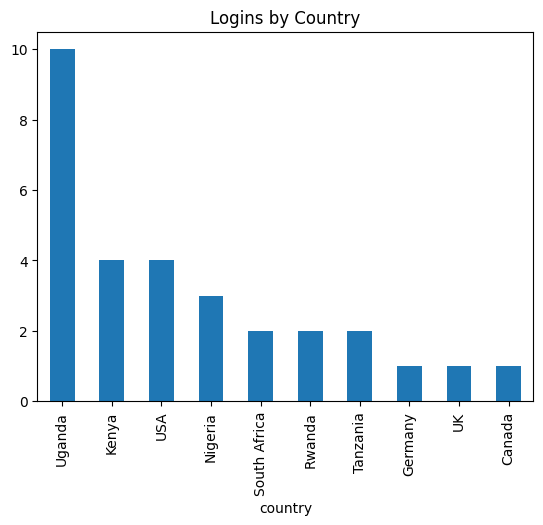

In [ ]:
df['country'].value_counts()

df['country'].value_counts().plot(kind='bar')
plt.title("Logins by Country")
plt.show()

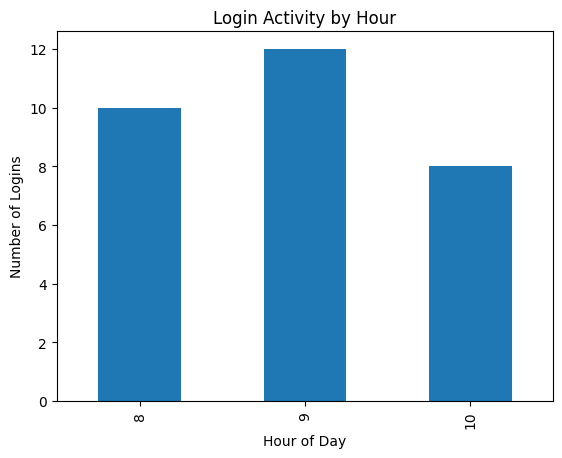

In [ ]:
# Extract hour from timestamp
df['hour'] = df['timestamp'].dt.hour

df['hour'].value_counts().sort_index()

df['hour'].value_counts().sort_index().plot(kind='bar')
plt.title("Login Activity by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Logins")
plt.show()

## Time-Based Login Analysis

Analyzing login activity over time helps identify unusual access patterns, such as spikes in login attempts or abnormal login hours.

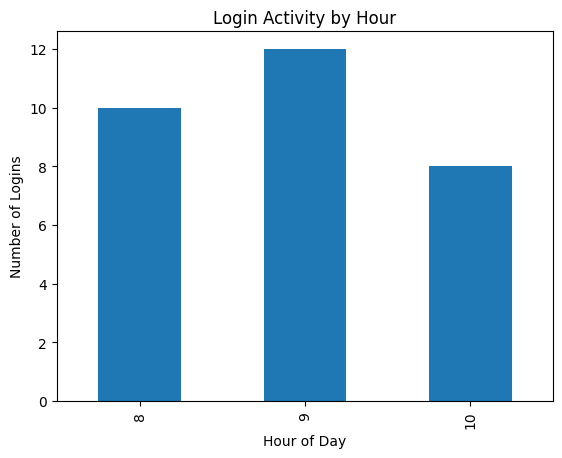

In [ ]:
# Extract hour from timestamp
df['hour'] = df['timestamp'].dt.hour

df['hour'].value_counts().sort_index()

df['hour'].value_counts().sort_index().plot(kind='bar')
plt.title("Login Activity by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Logins")
plt.show()

In [ ]:
failure_rate = df.groupby('user_id')['success'].apply(lambda x: (~x).mean())
failure_rate.sort_values(ascending=False)

user_id
user104    1.0
user103    1.0
user106    1.0
user109    1.0
user126    1.0
user124    1.0
user119    1.0
user117    1.0
user114    1.0
user112    1.0
user121    1.0
user102    0.5
user110    0.0
user105    0.0
user101    0.0
user108    0.0
user107    0.0
user111    0.0
user118    0.0
user116    0.0
user115    0.0
user113    0.0
user122    0.0
user120    0.0
user123    0.0
user125    0.0
Name: success, dtype: float64

This shows the proportion of failed login attempts per user. A high failure rate may indicate suspicious behavior or repeated unauthorized attempts.

In [ ]:
df['ip_address'].value_counts()

df[df['success'] == False]['ip_address'].value_counts()

ip_address
172.16.5.4      1
203.0.113.5     1
45.67.89.10     1
10.0.0.5        1
41.210.12.45    1
203.0.113.55    1
105.112.54.9    1
154.72.90.1     1
41.75.200.3     1
154.118.90.5    1
8.8.4.4         1
172.16.2.3      1
Name: count, dtype: int64

IP addresses with multiple failed attempts may represent malicious sources trying to gain access to the system.

Most logins come from a few countries. Logins from unusual locations could be suspicious.

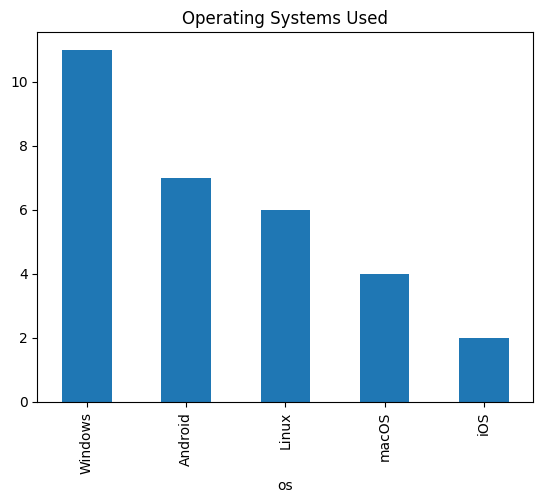

In [ ]:
df['os'].value_counts()

df['os'].value_counts().plot(kind='bar')
plt.title("Operating Systems Used")
plt.show()

In [ ]:
df['user_id'].value_counts()

user_id
user101    4
user102    2
user103    1
user104    1
user105    1
user106    1
user107    1
user108    1
user109    1
user110    1
user111    1
user112    1
user113    1
user114    1
user115    1
user116    1
user117    1
user118    1
user119    1
user120    1
user121    1
user122    1
user123    1
user124    1
user125    1
user126    1
Name: count, dtype: int64

Users with high login frequency should be monitored, especially if combined with failed attempts.

In [ ]:
# Users with failed logins
suspicious_users = df[df['success'] == False]['user_id'].value_counts()

# Users logging from multiple countries
multi_country_users = df.groupby('user_id')['country'].nunique()
multi_country_users[multi_country_users > 1]

Series([], Name: country, dtype: int64)

Users logging in from multiple countries may indicate compromised accounts.
Repeated failed logins suggest possible brute-force attacks.

## Conclusion

The analysis highlights several important observations about system usage. While most login attempts were successful, there are noticeable failed attempts that may indicate unauthorized access attempts. Certain users showed repeated login activity, which could require further monitoring.

Additionally, login activity from multiple locations suggests the possibility of shared or compromised accounts. These findings emphasize the importance of implementing stronger security measures such as monitoring failed attempts, restricting access after multiple failures, and tracking unusual login patterns.

Overall, the project demonstrates how basic data analysis techniques can be used to improve system security and detect potential threats.
An additional risk scoring approach was implemented to prioritize potentially suspicious login events, providing a simple but effective method for identifying threats.